# Parametric PINN Training (02 layout)

This notebook reuses the structure of **02_pinn_train.ipynb** but implements the
parametric/`ParamBC` logic from the dedicated parametric notebook.  

## Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import dataclass
import json
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import set_seed, get_device
from src.data import load_manifest_rows, load_case_manifest_row, ParamPINNBatch
from src.pinn import MLP, LossWeights

set_seed(42)
device = get_device()
print(f"Project root: {ROOT}")
print(f"Device: {device}")

MU_TIME_SAMPLES = 15

RUN_ID = datetime.now(timezone.utc).strftime("%Y_%m_%d_%H%M")
OUTDIR = ROOT / "outputs" / "parametric" / RUN_ID
OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"RUN_ID: {RUN_ID}")
print(f"OUTDIR: {OUTDIR}")

Project root: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu
RUN_ID: 2026_03_15_1905
OUTDIR: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_15_1905


## Data Loading and Case Split

In [2]:
manifest = ROOT / "data" / "manifest.csv"
rows = load_manifest_rows(manifest)
if len(rows) < 2:
    raise RuntimeError("Need at least two cases for train/held-out split.")

# deterministic split; keep final 20% as held-out
rows_sorted = sorted(rows, key=lambda r: r["case_id"])
n_val_cases = max(1, int(round(0.2 * len(rows_sorted))))
val_rows = rows_sorted[-n_val_cases:]
train_rows = rows_sorted[:-n_val_cases]

if len(train_rows) == 0:
    raise RuntimeError("Split produced no training cases.")

print("Train cases:", [r["case_id"] for r in train_rows])
print("Held-out cases:", [r["case_id"] for r in val_rows])

Train cases: ['const_10000', 'const_15000', 'const_5000', 'offset_sine_1', 'sine_A10000_T100', 'sine_A10000_T50']
Held-out cases: ['sine_A5000_T100', 'sine_A5000_T50']


## Data Preprocessing and Parametric Batch

In [3]:
def compute_mu_stats(cases):
    eps = 1e-8
    all_mu = np.array([c["mu_raw"] for c in cases])
    mu_min = all_mu.min(axis=0)
    mu_max = all_mu.max(axis=0)
    return {
        "mu_min": mu_min,
        "mu_max": mu_max,
        "eps": eps,
    }


def normalise_mu(mu_raw, mu_stats):
    eps = mu_stats["eps"]
    mu_min = mu_stats["mu_min"]
    mu_max = mu_stats["mu_max"]
    return 2.0 * (mu_raw - mu_min) / (mu_max - mu_min + eps) - 1.0


def _load_case_with_mu(row: dict) -> dict:
    c = load_case_manifest_row(row, root=ROOT)
    
    # Extract mu from boundary conditions at xi=0 and xi=1
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    
    tau_max = tau.max()
    tau_samples = np.linspace(0, tau_max, MU_TIME_SAMPLES)
    theta_series_0 = np.interp(tau_samples, tau, theta[0, :])  # xi=0
    theta_series_1 = np.interp(tau_samples, tau, theta[-1, :])  # xi=1
    
    # Compute time derivatives
    dtheta_dtau_0 = np.gradient(theta_series_0, tau_samples).astype(np.float32)
    dtheta_dtau_1 = np.gradient(theta_series_1, tau_samples).astype(np.float32)
    
    mu_raw = np.concatenate([theta_series_0, theta_series_1, dtheta_dtau_0, dtheta_dtau_1]).astype(np.float32)
    
    c["mu_raw"] = mu_raw
    c["mu"] = mu_raw  # Will be normalized later
    
    L = float(c["physical"]["L"])
    alpha = float(c["physical"]["alpha"])
    k = float(c["physical"]["k"])
    dT_ref = float(c["physical"]["dT_ref"])
    c["time_scale"] = np.float32((L**2) / alpha)         # t = tau * time_scale
    c["flux_scale"] = np.float32(k * dT_ref / L)          # theta_x = -q / flux_scale
    return c

train_cases = [_load_case_with_mu(r) for r in train_rows]
val_cases = [_load_case_with_mu(r) for r in val_rows]

mu_stats = compute_mu_stats(train_cases)
for c in (train_cases + val_cases):
    c["mu"] = normalise_mu(c["mu_raw"], mu_stats)

print(f"Loaded {len(train_cases)} train cases and {len(val_cases)} held-out cases.")
print("mu_stats min:", mu_stats["mu_min"][:5], "...")  # Show first 5
print("mu_stats max:", mu_stats["mu_max"][:5], "...")

# Example mu
if train_cases:
    print("Example mu:", train_cases[0]["mu"][:5], "...")

all_mu = np.stack([c["mu"] for c in (train_cases + val_cases)], axis=0)
print("mu_vector mins:", all_mu.min(axis=0)[:5], "...")
print("mu_vector maxs:", all_mu.max(axis=0)[:5], "...")

Loaded 6 train cases and 2 held-out cases.
mu_stats min: [0. 0. 0. 0. 0.] ...
mu_stats max: [0. 0. 0. 0. 0.] ...
Example mu: [-1. -1. -1. -1. -1.] ...
mu_vector mins: [-1. -1. -1. -1. -1.] ...
mu_vector maxs: [-1. -1. -1. -1. -1.] ...


In [4]:
# Check boundary traces differ
for c in train_cases[:3]:  # check first 3
    print(f"Case {c['case_id']}: mu_raw[:5] = {c['mu_raw'][:5]}")
print("...")

Case const_10000: mu_raw[:5] = [0. 0. 0. 0. 0.]
Case const_15000: mu_raw[:5] = [0. 0. 0. 0. 0.]
Case const_5000: mu_raw[:5] = [0. 0. 0. 0. 0.]
...


## Create Batch

In [5]:
# collocation points (same for train/val)
rng = np.random.default_rng(42)
n_r = 1500

# determine nondimensional tau range across training cases (use for sampling)
tau_max = max(c["nondim"]["tau"].max() for c in train_cases)
xi_r = rng.uniform(0.0, 1.0, size=(n_r, 1)).astype(np.float32)
tau_r = rng.uniform(0.0, float(tau_max), size=(n_r, 1)).astype(np.float32)

# assemble training batch using param cases
# (concatenate nondimensional data from all train cases)
xi_data_train = []
tau_data_train = []
theta_data_train = []
mu_data_train = []

for c in train_cases:
    # use nondimensional arrays provided by load_case_manifest_row
    xi = c["nondim"]["xi"]            # (Nx,)
    tau = c["nondim"]["tau"]          # (Nt,)
    theta = c["nondim"]["theta"]      # (Nx, Nt)

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    xi_data_train.append(xi_grid.reshape(-1, 1))
    tau_data_train.append(tau_grid.reshape(-1, 1))
    theta_data_train.append(theta.reshape(-1, 1))
    mu_data_train.append(np.repeat(c["mu"].reshape(1, -1), xi_grid.size, axis=0))

xi_data_train = np.vstack(xi_data_train).astype(np.float32)
tau_data_train = np.vstack(tau_data_train).astype(np.float32)
theta_data_train = np.vstack(theta_data_train).astype(np.float32)
mu_data_train = np.vstack(mu_data_train).astype(np.float32)

# same for validation
xi_data_val = []
tau_data_val = []
theta_data_val = []
mu_data_val = []
for c in val_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    xi_data_val.append(xi_grid.reshape(-1, 1))
    tau_data_val.append(tau_grid.reshape(-1, 1))
    theta_data_val.append(theta.reshape(-1, 1))
    mu_data_val.append(np.repeat(c["mu"].reshape(1, -1), xi_grid.size, axis=0))

xi_data_val = np.vstack(xi_data_val).astype(np.float32)
tau_data_val = np.vstack(tau_data_val).astype(np.float32)
theta_data_val = np.vstack(theta_data_val).astype(np.float32)
mu_data_val = np.vstack(mu_data_val).astype(np.float32)

# create train/val batches
torch_zero = lambda *shape: torch.zeros(shape, dtype=torch.float32, device=device)

# sample mu for collocation points from training cases
rng_mu = np.random.default_rng(42)
mu_samples = np.array([c["mu"] for c in train_cases])
mu_r_train = rng_mu.choice(mu_samples, size=n_r, replace=True).astype(np.float32)
mu_r_val = rng_mu.choice(mu_samples, size=n_r // 5, replace=True).astype(np.float32)

# IC points
n_ic = 1000
xi_ic = rng.uniform(0.0, 1.0, size=(n_ic, 1)).astype(np.float32)
tau_ic = np.zeros((n_ic, 1), dtype=np.float32)
mu_ic = rng_mu.choice(mu_samples, size=n_ic, replace=True).astype(np.float32)
theta_ic = np.zeros((n_ic, 1), dtype=np.float32)

# BC points (Dirichlet at xi=0, Neumann/flux at xi=1)
# Helper to interpolate per-case flux values at arbitrary tau points.
def _interp_flux_for_case(case, tau_query):
    tau_case = case["nondim"]["tau"].reshape(-1)
    flux_case = case["nondim"]["flux_bc_known"].reshape(-1)
    return np.interp(tau_query.flatten(), tau_case, flux_case).reshape(-1, 1).astype(np.float32)

n_bc = 1000
# Dirichlet boundary points (xi=0, theta=0)
n_bc_dirichlet = n_bc // 2
xi_bc_dirichlet = np.zeros((n_bc_dirichlet, 1), dtype=np.float32)
tau_bc_dirichlet = rng.uniform(0.0, float(tau_max), size=(n_bc_dirichlet, 1)).astype(np.float32)
case_idx_dirichlet = rng_mu.integers(0, len(train_cases), size=n_bc_dirichlet)
mu_bc_dirichlet = np.stack([train_cases[i]["mu"] for i in case_idx_dirichlet], axis=0)

# Neumann/flux boundary points (xi=1, flux from case)
n_bc_neumann = n_bc - n_bc_dirichlet
xi_bc_neumann = np.ones((n_bc_neumann, 1), dtype=np.float32)
tau_bc_neumann = rng.uniform(0.0, float(tau_max), size=(n_bc_neumann, 1)).astype(np.float32)
case_idx_neumann = rng_mu.integers(0, len(train_cases), size=n_bc_neumann)
mu_bc_neumann = np.stack([train_cases[i]["mu"] for i in case_idx_neumann], axis=0)
flux_bc_neumann = np.vstack([
    _interp_flux_for_case(train_cases[i], tau_bc_neumann[j : j + 1])
    for j, i in enumerate(case_idx_neumann)
])

# Combine into a single BC batch (NaN used to mask the unused targets per point)
xi_bc = np.vstack([xi_bc_dirichlet, xi_bc_neumann])
tau_bc = np.vstack([tau_bc_dirichlet, tau_bc_neumann])
mu_bc = np.vstack([mu_bc_dirichlet, mu_bc_neumann])
theta_bc = np.vstack([
    np.zeros_like(xi_bc_dirichlet, dtype=np.float32),
    np.full_like(xi_bc_neumann, np.nan, dtype=np.float32),
])
flux_bc = np.vstack([
    np.full_like(xi_bc_dirichlet, np.nan, dtype=np.float32),
    flux_bc_neumann,
])

train_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_train, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc, dtype=torch.float32, device=device),
    bc_time_scale=torch_zero(0, 1),
    bc_flux_scale=torch_zero(0, 1),
    flux_bc=torch.tensor(flux_bc, dtype=torch.float32, device=device),
    xi_data=torch.tensor(xi_data_train, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_train, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_train, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_train, dtype=torch.float32, device=device),
)

# Validation batch: reuse same BC structure but with held-out cases
case_idx_dirichlet_val = rng_mu.integers(0, len(val_cases), size=n_bc_dirichlet)
mu_bc_dirichlet_val = np.stack([val_cases[i]["mu"] for i in case_idx_dirichlet_val], axis=0)

case_idx_neumann_val = rng_mu.integers(0, len(val_cases), size=n_bc_neumann)
mu_bc_neumann_val = np.stack([val_cases[i]["mu"] for i in case_idx_neumann_val], axis=0)
flux_bc_neumann_val = np.vstack([
    _interp_flux_for_case(val_cases[i], tau_bc_neumann[j : j + 1])
    for j, i in enumerate(case_idx_neumann_val)
])

mu_bc_val = np.vstack([mu_bc_dirichlet_val, mu_bc_neumann_val])
theta_bc_val = np.vstack([
    np.zeros_like(xi_bc_dirichlet, dtype=np.float32),
    np.full_like(xi_bc_neumann, np.nan, dtype=np.float32),
])
flux_bc_val = np.vstack([
    np.full_like(xi_bc_dirichlet, np.nan, dtype=np.float32),
    flux_bc_neumann_val,
])

val_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r[: n_r//5], dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r[: n_r//5], dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_val, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc_val, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc_val, dtype=torch.float32, device=device),
    bc_time_scale=torch_zero(0, 1),
    bc_flux_scale=torch_zero(0, 1),
    flux_bc=torch.tensor(flux_bc_val, dtype=torch.float32, device=device),
    xi_data=torch.tensor(xi_data_val, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_val, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_val, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_val, dtype=torch.float32, device=device),
)

print("Data loaded and split successfully (parametric).")
print(f"mu_r shape: {train_batch.mu_r.shape}")


Data loaded and split successfully (parametric).
mu_r shape: torch.Size([1500, 60])


## Training

In [6]:
# build model and weights
model = MLP(in_dim=2 + mu_data_train.shape[1], hidden=64, layers=3).to(device)
weights = LossWeights(w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0)  # Enforce BCs: theta=0 at xi=0 (Dirichlet) + flux at xi=1 (Neumann)

# Configurable training parameters
N_DATA_BATCH = 5000
EVAL_EVERY = 500

run_dir = OUTDIR  # Save models per run in OUTDIR

print(f"Using device: {device}")
print(f"n_r (collocation points): {n_r}")
print(f"N_DATA_BATCH (data loss subsample): {N_DATA_BATCH}")
print(f"eval_every: {EVAL_EVERY}")

best_path = None
import importlib
import src.pinn
importlib.reload(src.pinn)
import src.train
importlib.reload(src.train)
from src.train import train_adam, train_lbfgs

best_path = train_adam(
    model,
    train_batch,
    weights,
    lr=1e-3,
    run_dir=run_dir,
    val_batch=val_batch,
    print_every=100,
    eval_every=EVAL_EVERY,
    patience_evals=8,
    plateau_window=5,
    plateau_rel_tol=0.01,
    pde_guardrail_rel=0.10,
    data_batch_size=N_DATA_BATCH,
    case_id="{RUN_ID}",
)

# polish with L-BFGS
best_lbfgs_path = train_lbfgs(  
    model,
    train_batch,
    weights,
    max_iter=500,
    run_dir=run_dir,
    case_id=f"{RUN_ID}",
)

print("Training completed.")

Using device: cpu
n_r (collocation points): 1500
N_DATA_BATCH (data loss subsample): 5000
eval_every: 500
[Adam] step 1/20000 | total=3.6966e+00 (pde=8.02e-03, ic=6.92e-01, bc=1.71e+00, data=1.28e+00) | val_rmse=7.15e-01 | val_pde=1.13e-02 | grad=3.63e+01 | 0.2s
[Adam] step 100/20000 | total=4.5175e-01 (pde=6.84e-03, ic=6.60e-02, bc=3.46e-01, data=3.33e-02) | val_rmse=nan | val_pde=nan | grad=2.28e-01 | 16.4s


KeyboardInterrupt: 

In [ ]:
# Final pre-run sanity checks

# Print model & input dimensions
print("Model:", model)
print("Input dim (should be 2 + mu_dim):", 2 + mu_data_train.shape[1])
print("mu_dim:", mu_data_train.shape[1])
print("Train batch sizes:")
print("  xi_r, tau_r, mu_r:", train_batch.xi_r.shape, train_batch.tau_r.shape, train_batch.mu_r.shape)
print("  xi_data, tau_data, mu_data:", train_batch.xi_data.shape, train_batch.tau_data.shape, train_batch.mu_data.shape)
print("  xi_ic, tau_ic:", train_batch.xi_ic.shape, train_batch.tau_ic.shape)
print("  xi_bc, tau_bc:", train_batch.xi_bc.shape, train_batch.tau_bc.shape)

# Quick forward-pass sanity check
with torch.no_grad():
    X_sample = torch.cat([
        train_batch.xi_data[:10],
        train_batch.tau_data[:10],
        train_batch.mu_data[:10],
    ], dim=1).to(device)
    y_pred = model(X_sample)
print("Forward pass output shape (should be (N,1)):", y_pred.shape)

# Compute and report losses (training and validation)
from src.train import compute_losses_eval

loss_train, logs_train = compute_losses_eval(model, train_batch, weights, create_graph=False)
loss_val, logs_val = compute_losses_eval(model, val_batch, weights, create_graph=False)

print("Train losses:")
for k, v in logs_train.items():
    print(f"  {k}: {v:.4e}")
print("Validation losses:")
for k, v in logs_val.items():
    print(f"  {k}: {v:.4e}")

# Verify losses are finite
assert torch.isfinite(loss_train).all(), "Train loss is not finite"
assert torch.isfinite(loss_val).all(), "Val loss is not finite"

print("Sanity checks passed. Model is ready for training.")

Model: MLP(
  (net): Sequential(
    (0): Linear(in_features=62, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Input dim (should be 2 + mu_dim): 62
mu_dim: 60
Train batch sizes:
  xi_r, tau_r, mu_r: torch.Size([1500, 1]) torch.Size([1500, 1]) torch.Size([1500, 60])
  xi_data, tau_data, mu_data: torch.Size([78156, 1]) torch.Size([78156, 1]) torch.Size([78156, 60])
  xi_ic, tau_ic: torch.Size([1000, 1]) torch.Size([1000, 1])
  xi_bc, tau_bc: torch.Size([1000, 1]) torch.Size([1000, 1])
Forward pass output shape (should be (N,1)): torch.Size([10, 1])
Train losses:
  total: 8.2649e-05
  pde: 1.8430e-05
  ic: 3.0696e-05
  bc: 3.7447e-06
  bc_monitor: 0.0000e+00
  data: 2.9779e-05
  smooth: 0.0000e+00
Validation losses:
  total: 6.8146e-05
  pde: 2.2638e-05
  ic: 3.0696e-05
  bc: 3.7447e-06
  bc_monitor: 0.0000e+00
  data: 1.1068e-05
  smooth: 0.0000e+00
S

## Plot

In [ ]:
# Select a held-out case for plotting (e.g., first validation case)
test_case = val_cases[0]  # Change index to plot different cases
case_id = test_case["case_id"]
print(f"Plotting for held-out case: {case_id}")

# Extract nondimensional data
xi = test_case["nondim"]["xi"]
tau = test_case["nondim"]["tau"]
theta_true = test_case["nondim"]["theta"]
mu_case = test_case["mu"]  # Normalized mu for this case

# Physical scales
T_left = float(test_case["physical"]["T_ref"])
dT = float(test_case["physical"]["dT_ref"])
L = float(test_case["physical"]["L"])
alpha = float(test_case["physical"]["alpha"])
k = float(test_case["physical"]["k"])

# Predict temperature field for this case
# Since parametric, we need to predict on the grid with mu
xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
xi_flat = xi_grid.flatten()
tau_flat = tau_grid.flatten()
mu_flat = np.tile(mu_case, (xi_flat.size, 1))  # Repeat mu for each point

X_pred = np.column_stack([xi_flat, tau_flat, mu_flat]).astype(np.float32)
X_pred_tensor = torch.tensor(X_pred, device=device)

model.eval()
with torch.no_grad():
    theta_pred_flat = model(X_pred_tensor).cpu().numpy().flatten()

theta_pred = theta_pred_flat.reshape(xi_grid.shape)

# Convert to physical temperature
T_true = T_left + dT * theta_true
T_pred = T_left + dT * theta_pred

print("Predicted theta shape:", theta_pred.shape)
print("True theta shape:", theta_true.shape)


Plotting for held-out case: sine_A5000_T100
Predicted theta shape: (51, 1001)
True theta shape: (51, 1001)


Saved boundary profiles plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_15_1734\boundary_profiles_sine_A5000_T100.png


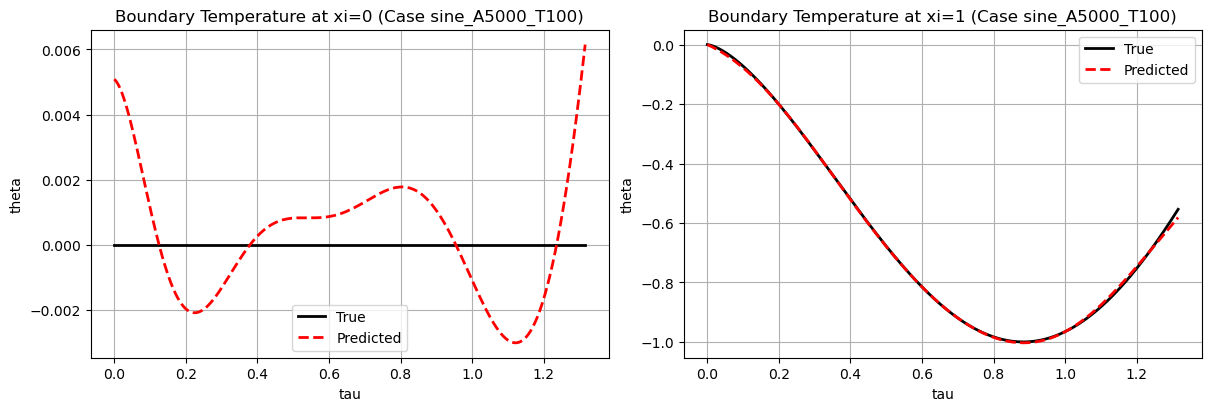

In [ ]:
# Plot boundary temperature profiles (xi=0 and xi=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# xi=0 (left boundary)
axes[0].plot(tau, theta_true[0, :], 'k-', label='True', linewidth=2)
axes[0].plot(tau, theta_pred[0, :], 'r--', label='Predicted', linewidth=2)
axes[0].set_title(f'Boundary Temperature at xi=0 (Case {case_id})')
axes[0].set_xlabel('tau')
axes[0].set_ylabel('theta')
axes[0].legend()
axes[0].grid(True)

# xi=1 (right boundary)
axes[1].plot(tau, theta_true[-1, :], 'k-', label='True', linewidth=2)
axes[1].plot(tau, theta_pred[-1, :], 'r--', label='Predicted', linewidth=2)
axes[1].set_title(f'Boundary Temperature at xi=1 (Case {case_id})')
axes[1].set_xlabel('tau')
axes[1].set_ylabel('theta')
axes[1].legend()
axes[1].grid(True)

# Save the plot
boundary_plot_path = OUTDIR / f"boundary_profiles_{case_id}.png"
plt.savefig(boundary_plot_path, dpi=150, bbox_inches='tight')
print(f"Saved boundary profiles plot to: {boundary_plot_path}")

plt.show()


Saved temperature comparison plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_15_1734\temperature_comparison_sine_A5000_T100.png


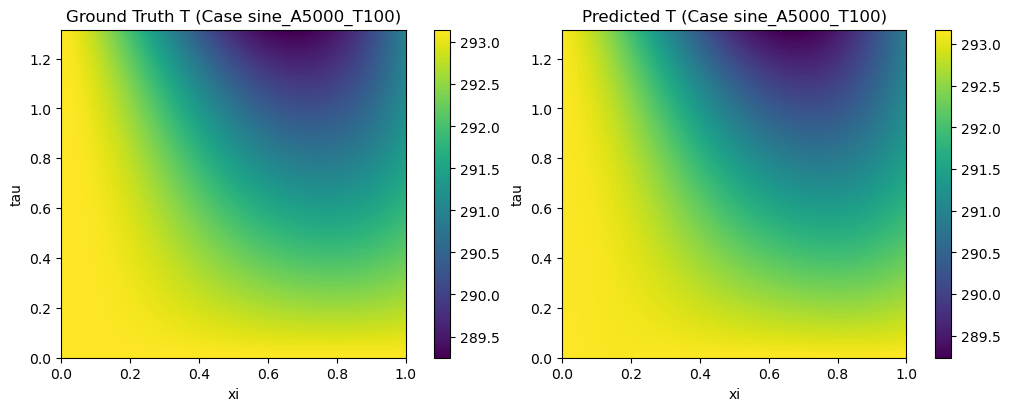

RMSE for case sine_A5000_T100: 1.9406e-03


In [ ]:
# Quick comparison plot (ground truth vs prediction)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(T_true, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[0].set_title(f'Ground Truth T (Case {case_id})')
axes[0].set_xlabel('xi')
axes[0].set_ylabel('tau')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(T_pred, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[1].set_title(f'Predicted T (Case {case_id})')
axes[1].set_xlabel('xi')
axes[1].set_ylabel('tau')
plt.colorbar(im1, ax=axes[1])

# Save the plot
plot_path = OUTDIR / f"temperature_comparison_{case_id}.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Saved temperature comparison plot to: {plot_path}")

plt.show()

# Compute RMSE for this case
mse_case = np.mean((theta_pred - theta_true) ** 2)
rmse_case = np.sqrt(mse_case)
print(f"RMSE for case {case_id}: {rmse_case:.4e}")


## Validation & Metrics

Loaded checkpoint: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_15_1734\{RUN_ID}_best.pt
Validation logs:
  total: 6.8146e-05
  pde: 2.2638e-05
  ic: 3.0696e-05
  bc: 3.7447e-06
  bc_monitor: 0.0000e+00
  data: 1.1068e-05
  smooth: 0.0000e+00
Validation RMSE (data): 3.3268e-03
Saved validation scatter plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_15_1734\validation_scatter.png


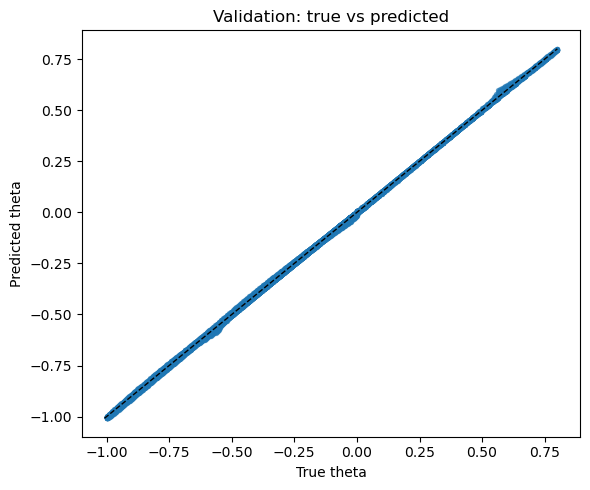

Saved validation metrics to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_15_1734\validation_metrics.txt


In [ ]:
# example validation on held-out data
import src.train as train_mod
importlib.reload(train_mod)
from src.train import compute_losses_eval

# load checkpoint
ckpt = best_path if best_path is not None else None
if ckpt is not None and ckpt.exists():
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state["state_dict"])
    model.to(device)
    print(f"Loaded checkpoint: {ckpt}")

val_loss, val_logs = compute_losses_eval(model, val_batch, weights, create_graph=False)
print("Validation logs:")
for k, v in val_logs.items():
    print(f"  {k}: {v:.4e}")

if getattr(val_batch, "xi_data", None) is not None:
    model.eval()
    with torch.no_grad():
        X_val = torch.cat([val_batch.xi_data, val_batch.tau_data, val_batch.mu_data], dim=1).to(device)
        y_true = val_batch.theta_data.to(device)
        y_pred = model(X_val)
    mse = torch.mean((y_pred - y_true) ** 2).item()
    rmse = mse ** 0.5
    print(f"Validation RMSE (data): {rmse:.4e}")
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true.cpu().numpy(), y_pred.detach().cpu().numpy(), s=8, alpha=0.6)
    mn = min(y_true.min().item(), y_pred.min().item())
    mx = max(y_true.max().item(), y_pred.max().item())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel("True theta")
    plt.ylabel("Predicted theta")
    plt.title("Validation: true vs predicted")
    plt.tight_layout()
    
    # Save the plot to OUTDIR
    plot_path = OUTDIR / "validation_scatter.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Saved validation scatter plot to: {plot_path}")
    
    plt.show()
else:
    print("No interior validation data present in `val_batch` to plot.")

# Save validation metrics to OUTDIR
metrics_path = OUTDIR / "validation_metrics.txt"
with open(metrics_path, 'w') as f:
    f.write("Validation Metrics\n")
    f.write("==================\n")
    for k, v in val_logs.items():
        f.write(f"{k}: {v:.6e}\n")
    f.write(f"rmse_data: {rmse:.6e}\n")
print(f"Saved validation metrics to: {metrics_path}")
    

## Upload and update

In [ ]:
from src.experiment_logging import append_arch_search_result, compare_arch_to_best, ensure_arch_search_csv, load_best_arch_result
from sklearn.model_selection import train_test_split
import math
import subprocess

In [ ]:
# Architecture experiment logger
results_csv = ROOT / "results" / "arch_search.csv"
ensure_arch_search_csv(str(results_csv))
baseline_best = load_best_arch_result(str(results_csv), metric="val_rmse_data")

def _safe_git_commit() -> str:
    try:
        out = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=ROOT,
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout.strip()
    except Exception:
        return ""

def _first_linear(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Linear):
            return m
    return None

def _activation_name(module):
    for m in module.modules():
        if isinstance(m, (torch.nn.Tanh, torch.nn.ReLU, torch.nn.GELU, torch.nn.Sigmoid, torch.nn.SiLU, torch.nn.ELU, torch.nn.LeakyReLU)):
            return m.__class__.__name__.lower()
    return "unknown"

first_linear = _first_linear(model)
n_neurons = int(first_linear.out_features) if first_linear is not None else None
n_linear = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))
n_hidden_layers = max(n_linear - 1, 0)

adam_steps = int(globals().get("N_EPOCHS", globals().get("steps", 1000)))
lbfgs_iters = int(globals().get("max_iter", 500)) if "best_lbfgs_path" in globals() else 0
optimizer_name = "adam+lbfgs" if "best_lbfgs_path" in globals() else "adam"

current_result = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "git_commit": _safe_git_commit(),
    "seed": 42,
    "n_layers": n_hidden_layers,
    "n_neurons": n_neurons,
    "activation": _activation_name(model),
    "optimizer": optimizer_name,
    "epochs": adam_steps + lbfgs_iters,
    "lr": 1e-3,
    "n_colloc": int(globals().get("n_r", 50000)),
    "n_boundary": int(getattr(train_batch, "xi_bc", torch.empty(0, 1)).shape[0]),
    "n_initial": int(getattr(train_batch, "xi_ic", torch.empty(0, 1)).shape[0]),
    "n_data": int(getattr(train_batch, "xi_data", torch.empty(0, 1)).shape[0]),
    "loss_total": float(val_logs.get("total", math.nan)),
    "loss_pde": float(val_logs.get("pde", math.nan)),
    "loss_ic": float(val_logs.get("ic", math.nan)),
    "loss_bc": float(val_logs.get("bc", math.nan)),
    "loss_data": float(val_logs.get("data", math.nan)),
    "val_rmse_data": float(rmse),
    "val_pde_loss": float(val_logs.get("pde", math.nan)),
}

improved, reason = compare_arch_to_best(current_result, baseline_best)
append_arch_search_result(str(results_csv), current_result)

def _fmt(x):
    try:
        v = float(x)
        if math.isfinite(v):
            return f"{v:.6e}"
    except Exception:
        pass
    return "nan"

print()
print("Architecture comparison:")
if baseline_best is None:
    print("Baseline best metrics: none (first recorded run)")
else:
    print(
        "Baseline best metrics: "
        f"val_rmse_data={_fmt(baseline_best.get('val_rmse_data'))}, "
        f"val_pde_loss={_fmt(baseline_best.get('val_pde_loss'))}, "
        f"loss_total={_fmt(baseline_best.get('loss_total'))}"
    )

print(
    "Current metrics: "
    f"val_rmse_data={_fmt(current_result.get('val_rmse_data'))}, "
    f"val_pde_loss={_fmt(current_result.get('val_pde_loss'))}, "
    f"loss_total={_fmt(current_result.get('loss_total'))}"
)
print(("? IMPROVED: " if improved else "? NOT IMPROVED: ") + reason)
print(f"Logged run to {results_csv}")




Architecture comparison:
Baseline best metrics: val_rmse_data=3.210986e-03, val_pde_loss=2.509391e-05, loss_total=5.884074e-05
Current metrics: val_rmse_data=3.326805e-03, val_pde_loss=2.263840e-05, loss_total=6.814628e-05
? NOT IMPROVED: RMSE gain -1.158193e-04 is below threshold 1.000000e-04.
Logged run to c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\results\arch_search.csv


In [ ]:
log_path = Path(ROOT, "results", "experiment_log.csv")
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df.tail(5))
else:
    print(f"No log found at {log_path}")

,experiment_id,date_time_utc,commit_hash,python_version,torch_version,cuda_available,device,random_seed,case_id,data_paths,...,final_total_loss,final_pde_loss,final_bc_loss,final_ic_loss,final_data_loss,final_grad_norm,l2_error_temperature,max_abs_error,relative_l2_error,r2_score
0,20260216T153205Z_const_5000_596ff96_19ff91,2026-02-16T15:32:05.004343+00:00,596ff96,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.001084,0.000171,0.000001,0.000576,0.000336,NaN,NaN,NaN,NaN,NaN
1,20260216T161524Z_const_5000_775133c_437d6a,2026-02-16T16:15:24.247973+00:00,775133c,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002162,0.000349,0.000325,0.001451,0.000037,NaN,NaN,NaN,NaN,NaN
2,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
3,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
